In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. импорт библиотек
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
import sys
import os

project_root = '/content/drive/MyDrive/sort_model'
if project_root not in sys.path:
    sys.path.append(project_root)

# проверяем, что папка src есть в project_root
assert os.path.isdir(os.path.join(project_root, 'src')), "folder src not found in project root"

In [ ]:
from src.train import train_model
from src.dataset_from_csv import GarbageDatasetFromCSV

In [ ]:
# задаём преобразования
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# путь до датасета и csv
dataset_root = '/content/drive/MyDrive/sort_model/garbage-dataset'
csv_path = '/content/drive/MyDrive/sort_model/image_split.csv'

# создаём датасеты
train_dataset = GarbageDatasetFromCSV(csv_path, split='train', transform=transform, root_dir=dataset_root)
val_dataset = GarbageDatasetFromCSV(csv_path, split='val', transform=transform, root_dir=dataset_root)

# загрузчики
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

Using device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10 — train_loss: 0.7445, val_loss: 0.7527, val_acc: 0.7681
Epoch 2/10 — train_loss: 0.4684, val_loss: 0.5269, val_acc: 0.8305
Epoch 3/10 — train_loss: 0.3630, val_loss: 0.4532, val_acc: 0.8527
Epoch 4/10 — train_loss: 0.2876, val_loss: 0.4120, val_acc: 0.8662
Epoch 5/10 — train_loss: 0.2349, val_loss: 0.4644, val_acc: 0.8662
Epoch 6/10 — train_loss: 0.1948, val_loss: 0.5912, val_acc: 0.8504
Epoch 7/10 — train_loss: 0.1635, val_loss: 0.6119, val_acc: 0.8392
Epoch 8/10 — train_loss: 0.1328, val_loss: 0.4974, val_acc: 0.8675
Epoch 9/10 — train_loss: 0.1123, val_loss: 0.6874, val_acc: 0.8365
Epoch 10/10 — train_loss: 0.0857, val_loss: 0.5174, val_acc: 0.8797
Saved trained model to models/baseline_resnet18_new.pth


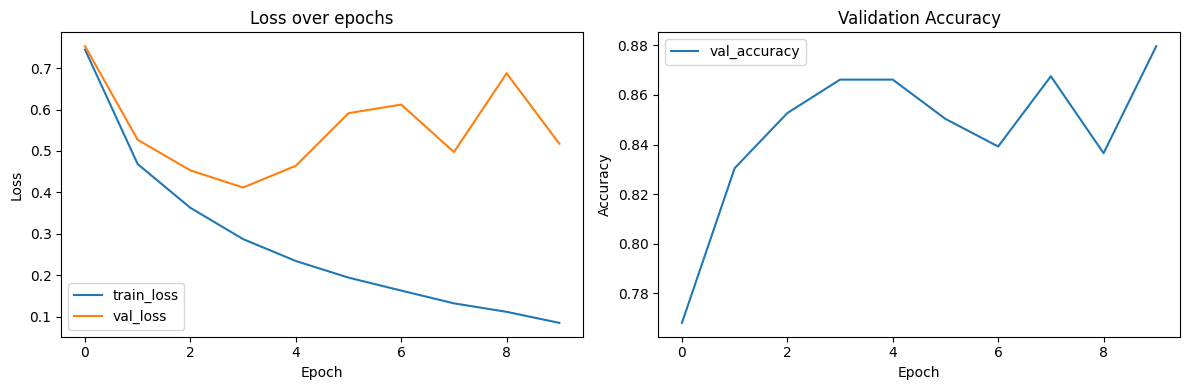

In [6]:
train_model(train_loader, val_loader, num_classes=10, device='cuda', epochs=10)

In [7]:
import os

print(os.getcwd())  # покажет текущую директорию
print(os.listdir('models'))  # покажет содержимое папки models

/content
['training_plot.png', 'baseline_resnet18_new.pth']


In [ ]:
os.listdir('/content/')

['.config', 'models', 'drive', 'sample_data']

In [8]:
import shutil

shutil.copy('/content/models/baseline_resnet18_new.pth', '/content/drive/MyDrive/sort_model/models/baseline_resnet18_new.pth')


'/content/drive/MyDrive/sort_model/models/baseline_resnet18_new.pth'